In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                              accuracy_score, f1_score)
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Libraries loaded!")

Libraries loaded!


In [6]:
# Load processed datasets
btc_train = pd.read_csv('../data/processed/BTC_USDT_train.csv')
btc_test  = pd.read_csv('../data/processed/BTC_USDT_test.csv')
eth_train = pd.read_csv('../data/processed/ETH_USDT_train.csv')
eth_test  = pd.read_csv('../data/processed/ETH_USDT_test.csv')

print(f"BTC train: {btc_train.shape} | {btc_train['timestamp'].iloc[0]} → {btc_train['timestamp'].iloc[-1]}")
print(f"BTC test:  {btc_test.shape}  | {btc_test['timestamp'].iloc[0]} → {btc_test['timestamp'].iloc[-1]}")
print(f"\nETH train: {eth_train.shape} | {eth_train['timestamp'].iloc[0]} → {eth_train['timestamp'].iloc[-1]}")
print(f"ETH test:  {eth_test.shape}  | {eth_test['timestamp'].iloc[0]} → {eth_test['timestamp'].iloc[-1]}")

# Feature columns — all new features included
FEATURE_COLS = [
    'ma20', 'ma50', 'ma200', 'rsi', 'returns', 'vol_20',
    'macd', 'macd_signal', 'macd_diff',
    'bb_high', 'bb_low', 'bb_mid', 'bb_width', 'bb_pct',
    'atr', 'stoch_rsi', 'stoch_rsi_k', 'stoch_rsi_d',
    'volume_ratio', 'dist_ma200', 'dist_ma50',
    'hour', 'day_of_week',
    'close_lag_1', 'returns_lag_1',
    'close_lag_2', 'returns_lag_2',
    'close_lag_3', 'returns_lag_3',
    'close_lag_6', 'returns_lag_6',
    'close_lag_12', 'returns_lag_12',
    'close_lag_24', 'returns_lag_24'
]

# Filter to only existing columns
FEATURE_COLS = [f for f in FEATURE_COLS if f in btc_train.columns]
print(f"\nFeatures used: {len(FEATURE_COLS)}")
print(FEATURE_COLS)
import pandas as pd
btc_test_check = pd.read_csv('../data/processed/BTC_USDT_test.csv')
print("BTC test label distribution:")
print(btc_test_check['label'].value_counts())
print(f"Total rows: {len(btc_test_check)}")

BTC train: (34900, 44) | 2019-01-17 14:00:00 → 2024-10-06 13:00:00
BTC test:  (12519, 44)  | 2024-10-06 15:00:00 → 2026-03-12 05:00:00

ETH train: (44861, 44) | 2019-01-17 14:00:00 → 2024-10-06 14:00:00
ETH test:  (12519, 44)  | 2024-10-06 15:00:00 → 2026-03-12 05:00:00

Features used: 35
['ma20', 'ma50', 'ma200', 'rsi', 'returns', 'vol_20', 'macd', 'macd_signal', 'macd_diff', 'bb_high', 'bb_low', 'bb_mid', 'bb_width', 'bb_pct', 'atr', 'stoch_rsi', 'stoch_rsi_k', 'stoch_rsi_d', 'volume_ratio', 'dist_ma200', 'dist_ma50', 'hour', 'day_of_week', 'close_lag_1', 'returns_lag_1', 'close_lag_2', 'returns_lag_2', 'close_lag_3', 'returns_lag_3', 'close_lag_6', 'returns_lag_6', 'close_lag_12', 'returns_lag_12', 'close_lag_24', 'returns_lag_24']
BTC test label distribution:
label
1    9116
2    1732
0    1671
Name: count, dtype: int64
Total rows: 12519


In [7]:
# Extract features and labels
btc_X_train = btc_train[FEATURE_COLS].fillna(0)
btc_y_train = btc_train['label']
btc_X_test  = btc_test[FEATURE_COLS].fillna(0)
btc_y_test  = btc_test['label']

eth_X_train = eth_train[FEATURE_COLS].fillna(0)
eth_y_train = eth_train['label']
eth_X_test  = eth_test[FEATURE_COLS].fillna(0)
eth_y_test  = eth_test['label']

# Check for remaining NaNs
print(f"BTC train NaNs: {btc_X_train.isnull().sum().sum()}")
print(f"BTC test NaNs:  {btc_X_test.isnull().sum().sum()}")
print(f"ETH train NaNs: {eth_X_train.isnull().sum().sum()}")
print(f"ETH test NaNs:  {eth_X_test.isnull().sum().sum()}")

# Scale features for Neural Network
btc_scaler = StandardScaler()
btc_X_train_sc = btc_scaler.fit_transform(btc_X_train)
btc_X_test_sc  = btc_scaler.transform(btc_X_test)

eth_scaler = StandardScaler()
eth_X_train_sc = eth_scaler.fit_transform(eth_X_train)
eth_X_test_sc  = eth_scaler.transform(eth_X_test)

print(f"\nBTC train: {btc_X_train.shape}")
print(f"BTC test:  {btc_X_test.shape}")
print(f"ETH train: {eth_X_train.shape}")
print(f"ETH test:  {eth_X_test.shape}")

LABEL_MAP = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
print(f"\nBTC train labels: {btc_y_train.value_counts().sort_index().rename(LABEL_MAP).to_dict()}")
print(f"ETH train labels: {eth_y_train.value_counts().sort_index().rename(LABEL_MAP).to_dict()}")

BTC train NaNs: 0
BTC test NaNs:  0
ETH train NaNs: 0
ETH test NaNs:  0

BTC train: (34900, 35)
BTC test:  (12519, 35)
ETH train: (44861, 35)
ETH test:  (12519, 35)

BTC train labels: {'SELL': 8050, 'HOLD': 17900, 'BUY': 8950}
ETH train labels: {'SELL': 10202, 'HOLD': 23106, 'BUY': 11553}


In [8]:
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
import numpy as np

results = {}

# Compute sample weights
btc_sample_weights = compute_sample_weight('balanced', btc_y_train)
eth_sample_weights = compute_sample_weight('balanced', eth_y_train)

# Compute class weights
btc_classes = np.array([0, 1, 2])
btc_cw = compute_class_weight('balanced', classes=btc_classes, y=btc_y_train)
btc_weight_dict = {0: btc_cw[0], 1: btc_cw[1], 2: btc_cw[2]}

eth_cw = compute_class_weight('balanced', classes=btc_classes, y=eth_y_train)
eth_weight_dict = {0: eth_cw[0], 1: eth_cw[1], 2: eth_cw[2]}

print(f"BTC class weights: {btc_weight_dict}")
print(f"ETH class weights: {eth_weight_dict}")

def train_and_evaluate(name, model, X_train, y_train, X_test, y_test, 
                        symbol, sample_weight=None):
    print(f"\nTraining {name} for {symbol}...")
    if sample_weight is not None:
        model.fit(X_train, y_train, sample_weight=sample_weight)
    else:
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    report = classification_report(y_test, y_pred,
                                   target_names=['SELL','HOLD','BUY'],
                                   output_dict=True)
    buy_recall  = report['BUY']['recall']
    sell_recall = report['SELL']['recall']
    print(f"  Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")
    print(f"  BUY recall: {buy_recall:.3f} | SELL recall: {sell_recall:.3f}")
    return model, acc, f1, y_pred

# ══════════════════════════════════════════════════════════
# BTC MODELS
# ══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("TRAINING BTC MODELS")
print("="*60)

# Neural Network — sample weights
nn_btc, nn_btc_acc, nn_btc_f1, nn_btc_pred = train_and_evaluate(
    "Neural Network",
    MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    ),
    btc_X_train_sc, btc_y_train,
    btc_X_test_sc,  btc_y_test, 'BTC',
    sample_weight=btc_sample_weights
)

# Random Forest — class_weight balanced
rf_btc, rf_btc_acc, rf_btc_f1, rf_btc_pred = train_and_evaluate(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    btc_X_train, btc_y_train,
    btc_X_test,  btc_y_test, 'BTC'
)

# XGBoost — sample weights
xgb_btc, xgb_btc_acc, xgb_btc_f1, xgb_btc_pred = train_and_evaluate(
    "XGBoost",
    xgb.XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    ),
    btc_X_train, btc_y_train,
    btc_X_test,  btc_y_test, 'BTC',
    sample_weight=btc_sample_weights
)

# LightGBM — class_weight balanced
lgb_btc, lgb_btc_acc, lgb_btc_f1, lgb_btc_pred = train_and_evaluate(
    "LightGBM",
    lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    ),
    btc_X_train, btc_y_train,
    btc_X_test,  btc_y_test, 'BTC'
)

results['BTC'] = {
    'Neural Network': {'acc': nn_btc_acc,  'f1': nn_btc_f1,  'model': nn_btc,  'pred': nn_btc_pred},
    'Random Forest':  {'acc': rf_btc_acc,  'f1': rf_btc_f1,  'model': rf_btc,  'pred': rf_btc_pred},
    'XGBoost':        {'acc': xgb_btc_acc, 'f1': xgb_btc_f1, 'model': xgb_btc, 'pred': xgb_btc_pred},
    'LightGBM':       {'acc': lgb_btc_acc, 'f1': lgb_btc_f1, 'model': lgb_btc, 'pred': lgb_btc_pred},
}

# ══════════════════════════════════════════════════════════
# ETH MODELS
# ══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("TRAINING ETH MODELS")
print("="*60)

# Neural Network — sample weights
nn_eth, nn_eth_acc, nn_eth_f1, nn_eth_pred = train_and_evaluate(
    "Neural Network",
    MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    ),
    eth_X_train_sc, eth_y_train,
    eth_X_test_sc,  eth_y_test, 'ETH',
    sample_weight=eth_sample_weights
)

# Random Forest — class_weight balanced
rf_eth, rf_eth_acc, rf_eth_f1, rf_eth_pred = train_and_evaluate(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    eth_X_train, eth_y_train,
    eth_X_test,  eth_y_test, 'ETH'
)

# XGBoost — sample weights
xgb_eth, xgb_eth_acc, xgb_eth_f1, xgb_eth_pred = train_and_evaluate(
    "XGBoost",
    xgb.XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    ),
    eth_X_train, eth_y_train,
    eth_X_test,  eth_y_test, 'ETH',
    sample_weight=eth_sample_weights
)

# LightGBM — class_weight balanced
lgb_eth, lgb_eth_acc, lgb_eth_f1, lgb_eth_pred = train_and_evaluate(
    "LightGBM",
    lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    ),
    eth_X_train, eth_y_train,
    eth_X_test,  eth_y_test, 'ETH'
)

results['ETH'] = {
    'Neural Network': {'acc': nn_eth_acc,  'f1': nn_eth_f1,  'model': nn_eth,  'pred': nn_eth_pred},
    'Random Forest':  {'acc': rf_eth_acc,  'f1': rf_eth_f1,  'model': rf_eth,  'pred': rf_eth_pred},
    'XGBoost':        {'acc': xgb_eth_acc, 'f1': xgb_eth_f1, 'model': xgb_eth, 'pred': xgb_eth_pred},
    'LightGBM':       {'acc': lgb_eth_acc, 'f1': lgb_eth_f1, 'model': lgb_eth, 'pred': lgb_eth_pred},
}

BTC class weights: {0: np.float64(1.445134575569358), 1: np.float64(0.6499068901303539), 2: np.float64(1.2998137802607077)}
ETH class weights: {0: np.float64(1.4657583480363328), 1: np.float64(0.6471767794800773), 2: np.float64(1.2943535589601547)}

TRAINING BTC MODELS

Training Neural Network for BTC...
  Accuracy: 0.5012 | Macro F1: 0.3784
  BUY recall: 0.227 | SELL recall: 0.443

Training Random Forest for BTC...
  Accuracy: 0.2884 | Macro F1: 0.2386
  BUY recall: 0.065 | SELL recall: 0.796

Training XGBoost for BTC...
  Accuracy: 0.3229 | Macro F1: 0.2737
  BUY recall: 0.099 | SELL recall: 0.780

Training LightGBM for BTC...
  Accuracy: 0.2879 | Macro F1: 0.2651
  BUY recall: 0.158 | SELL recall: 0.768

TRAINING ETH MODELS

Training Neural Network for ETH...
  Accuracy: 0.3998 | Macro F1: 0.3762
  BUY recall: 0.415 | SELL recall: 0.352

Training Random Forest for ETH...
  Accuracy: 0.4728 | Macro F1: 0.4008
  BUY recall: 0.278 | SELL recall: 0.311

Training XGBoost for ETH...
  Acc

In [9]:
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(f"{'Model':<20} {'BTC Acc':>10} {'BTC F1':>10} {'ETH Acc':>10} {'ETH F1':>10}")
print("-"*70)

for model_name in ['Neural Network', 'Random Forest', 'XGBoost', 'LightGBM']:
    btc_acc = results['BTC'][model_name]['acc']
    btc_f1  = results['BTC'][model_name]['f1']
    eth_acc = results['ETH'][model_name]['acc']
    eth_f1  = results['ETH'][model_name]['f1']
    avg_acc = (btc_acc + eth_acc) / 2
    print(f"{model_name:<20} {btc_acc:>10.4f} {btc_f1:>10.4f} {eth_acc:>10.4f} {eth_f1:>10.4f}  avg={avg_acc:.4f}")

print("="*70)

# Find best model per asset
best_btc = max(results['BTC'].items(), key=lambda x: x[1]['f1'])
best_eth = max(results['ETH'].items(), key=lambda x: x[1]['f1'])

print(f"\nBest BTC model: {best_btc[0]} (F1={best_btc[1]['f1']:.4f}, Acc={best_btc[1]['acc']:.4f})")
print(f"Best ETH model: {best_eth[0]} (F1={best_eth[1]['f1']:.4f}, Acc={best_eth[1]['acc']:.4f})")


MODEL COMPARISON SUMMARY
Model                   BTC Acc     BTC F1    ETH Acc     ETH F1
----------------------------------------------------------------------
Neural Network           0.5012     0.3784     0.3998     0.3762  avg=0.4505
Random Forest            0.2884     0.2386     0.4728     0.4008  avg=0.3806
XGBoost                  0.3229     0.2737     0.4601     0.4092  avg=0.3915
LightGBM                 0.2879     0.2651     0.4456     0.4054  avg=0.3668

Best BTC model: Neural Network (F1=0.3784, Acc=0.5012)
Best ETH model: XGBoost (F1=0.4092, Acc=0.4601)


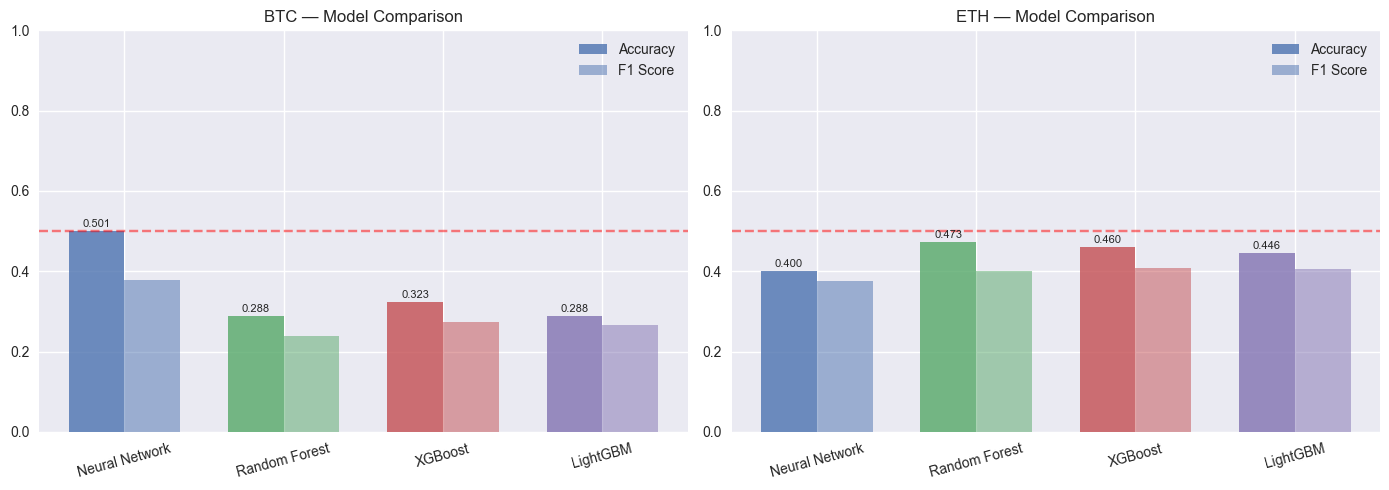

Chart saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = ['Neural Network', 'Random Forest', 'XGBoost', 'LightGBM']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax, symbol in zip(axes, ['BTC', 'ETH']):
    accs = [results[symbol][m]['acc'] for m in models]
    f1s  = [results[symbol][m]['f1']  for m in models]
    
    x = np.arange(len(models))
    w = 0.35
    bars1 = ax.bar(x - w/2, accs, w, label='Accuracy', color=colors, alpha=0.8)
    bars2 = ax.bar(x + w/2, f1s,  w, label='F1 Score', color=colors, alpha=0.5)
    
    ax.set_title(f'{symbol} — Model Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
    
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../docs/diagrams/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

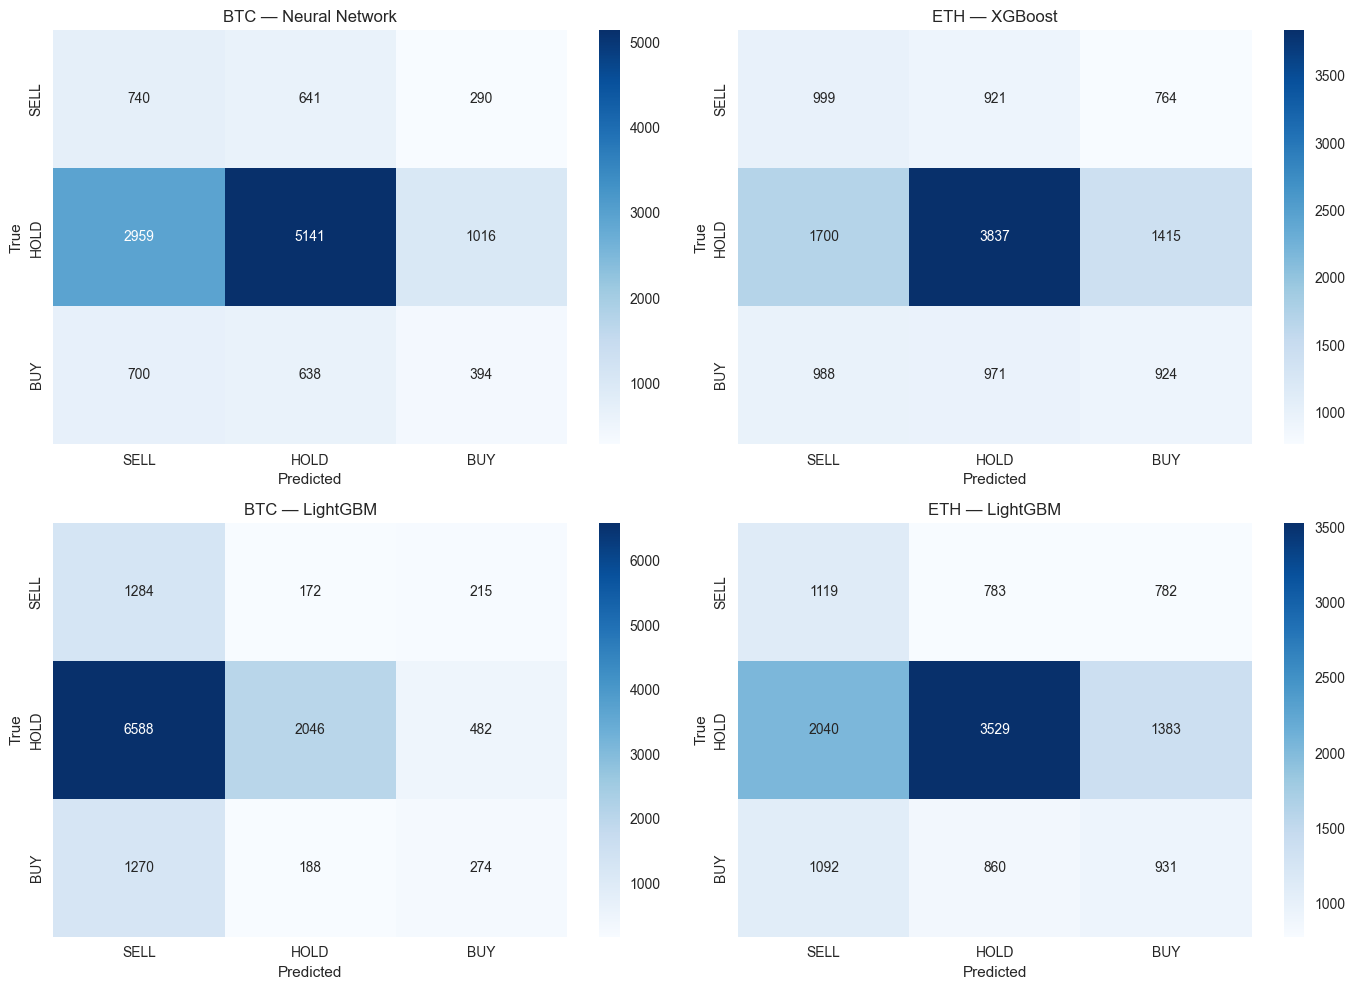

Chart saved!


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
label_names = ['SELL', 'HOLD', 'BUY']

best_btc_name = best_btc[0]
best_eth_name = best_eth[0]

pairs = [
    (results['BTC'][best_btc_name]['pred'], btc_y_test, f'BTC — {best_btc_name}'),
    (results['ETH'][best_eth_name]['pred'], eth_y_test, f'ETH — {best_eth_name}'),
    (results['BTC']['LightGBM']['pred'],    btc_y_test, 'BTC — LightGBM'),
    (results['ETH']['LightGBM']['pred'],    eth_y_test, 'ETH — LightGBM'),
]

for ax, (pred, true, title) in zip(axes.flat, pairs):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../docs/diagrams/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

Best BTC: Neural Network
Best ETH: XGBoost


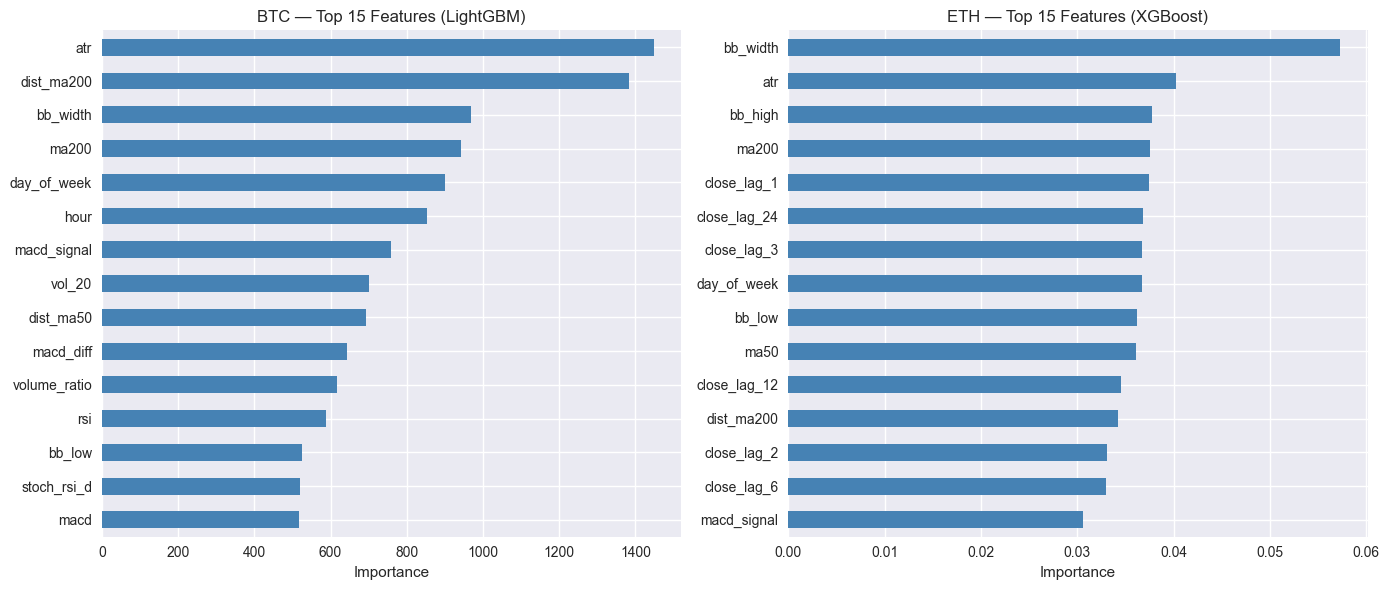

Chart saved!


In [12]:
# Determine best models by F1 score
best_btc_name = max(results['BTC'].items(), key=lambda x: x[1]['f1'])[0]
best_eth_name = max(results['ETH'].items(), key=lambda x: x[1]['f1'])[0]

print(f"Best BTC: {best_btc_name}")
print(f"Best ETH: {best_eth_name}")
# Show top features for best tree-based model
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (symbol, model_name) in zip(axes, [
    ('BTC', best_btc_name if best_btc_name != 'Neural Network' else 'LightGBM'),
    ('ETH', best_eth_name if best_eth_name != 'Neural Network' else 'LightGBM')
]):
    model = results[symbol][model_name]['model']
    
    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(
            model.feature_importances_, 
            index=FEATURE_COLS
        ).sort_values(ascending=True).tail(15)
        
        importances.plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f'{symbol} — Top 15 Features ({model_name})')
        ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../docs/diagrams/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [13]:
import numpy as np
from sklearn.metrics import classification_report

print("BTC Neural Network predictions breakdown:")
print(classification_report(btc_y_test, nn_btc_pred, 
                            target_names=['SELL', 'HOLD', 'BUY']))

print("\nPrediction distribution:")
unique, counts = np.unique(nn_btc_pred, return_counts=True)
label_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
for u, c in zip(unique, counts):
    print(f"  {label_map[u]}: {c} ({c/len(nn_btc_pred)*100:.1f}%)")

print("\nActual distribution in test set:")
unique, counts = np.unique(btc_y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_map[u]}: {c} ({c/len(btc_y_test)*100:.1f}%)")

BTC Neural Network predictions breakdown:
              precision    recall  f1-score   support

        SELL       0.17      0.44      0.24      1671
        HOLD       0.80      0.56      0.66      9116
         BUY       0.23      0.23      0.23      1732

    accuracy                           0.50     12519
   macro avg       0.40      0.41      0.38     12519
weighted avg       0.64      0.50      0.55     12519


Prediction distribution:
  SELL: 4399 (35.1%)
  HOLD: 6420 (51.3%)
  BUY: 1700 (13.6%)

Actual distribution in test set:
  SELL: 1671 (13.3%)
  HOLD: 9116 (72.8%)
  BUY: 1732 (13.8%)


In [14]:
import numpy as np
from sklearn.metrics import classification_report

# ── DIAGNOSTIC ───────────────────────────────────────────
print("="*60)
print("BTC Neural Network — Detailed Analysis")
print("="*60)
print(classification_report(btc_y_test, nn_btc_pred,
                            target_names=['SELL', 'HOLD', 'BUY']))

print("Prediction distribution:")
unique, counts = np.unique(nn_btc_pred, return_counts=True)
label_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
for u, c in zip(unique, counts):
    print(f"  {label_map[u]}: {c} ({c/len(nn_btc_pred)*100:.1f}%)")

print("\nActual distribution in test set:")
unique, counts = np.unique(btc_y_test.values, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_map[u]}: {c} ({c/len(btc_y_test)*100:.1f}%)")

print("\n" + "="*60)
print("ETH Neural Network — Detailed Analysis")
print("="*60)
print(classification_report(eth_y_test, nn_eth_pred,
                            target_names=['SELL', 'HOLD', 'BUY']))

print("Prediction distribution:")
unique, counts = np.unique(nn_eth_pred, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_map[u]}: {c} ({c/len(nn_eth_pred)*100:.1f}%)")

print("\nActual distribution in test set:")
unique, counts = np.unique(eth_y_test.values, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_map[u]}: {c} ({c/len(eth_y_test)*100:.1f}%)")

# ── DETERMINE BEST MODELS ────────────────────────────────
best_btc_name = max(results['BTC'].items(), key=lambda x: x[1]['f1'])[0]
best_eth_name = max(results['ETH'].items(), key=lambda x: x[1]['f1'])[0]

best_btc_model = results['BTC'][best_btc_name]['model']
best_eth_model = results['ETH'][best_eth_name]['model']

# ── SAVE MODELS ──────────────────────────────────────────
joblib.dump(best_btc_model, '../data/models/best_btc.joblib')
joblib.dump(best_eth_model, '../data/models/best_eth.joblib')
joblib.dump(btc_scaler,     '../data/models/best_btc_scaler.joblib')
joblib.dump(eth_scaler,     '../data/models/best_eth_scaler.joblib')

joblib.dump(nn_btc,  '../data/models/nn_btc.joblib')
joblib.dump(nn_eth,  '../data/models/nn_eth.joblib')
joblib.dump(rf_btc,  '../data/models/rf_btc.joblib')
joblib.dump(rf_eth,  '../data/models/rf_eth.joblib')
joblib.dump(xgb_btc, '../data/models/xgb_btc.joblib')
joblib.dump(xgb_eth, '../data/models/xgb_eth.joblib')
joblib.dump(lgb_btc, '../data/models/lgb_btc.joblib')
joblib.dump(lgb_eth, '../data/models/lgb_eth.joblib')

print("\n" + "="*60)
print("MODELS SAVED")
print("="*60)
print(f"Best BTC: {best_btc_name} (F1={results['BTC'][best_btc_name]['f1']:.4f})")
print(f"Best ETH: {best_eth_name} (F1={results['ETH'][best_eth_name]['f1']:.4f})")
print(f"\nFeatures used: {len(FEATURE_COLS)}")

BTC Neural Network — Detailed Analysis
              precision    recall  f1-score   support

        SELL       0.17      0.44      0.24      1671
        HOLD       0.80      0.56      0.66      9116
         BUY       0.23      0.23      0.23      1732

    accuracy                           0.50     12519
   macro avg       0.40      0.41      0.38     12519
weighted avg       0.64      0.50      0.55     12519

Prediction distribution:
  SELL: 4399 (35.1%)
  HOLD: 6420 (51.3%)
  BUY: 1700 (13.6%)

Actual distribution in test set:
  SELL: 1671 (13.3%)
  HOLD: 9116 (72.8%)
  BUY: 1732 (13.8%)

ETH Neural Network — Detailed Analysis
              precision    recall  f1-score   support

        SELL       0.24      0.35      0.28      2684
        HOLD       0.68      0.41      0.51      6952
         BUY       0.28      0.42      0.33      2883

    accuracy                           0.40     12519
   macro avg       0.40      0.39      0.38     12519
weighted avg       0.49      0.